Anode saturates (theta_a -> 1) at t = 580.0 s ; cathode capacity at that point = 173.8132748251627 mAh/g


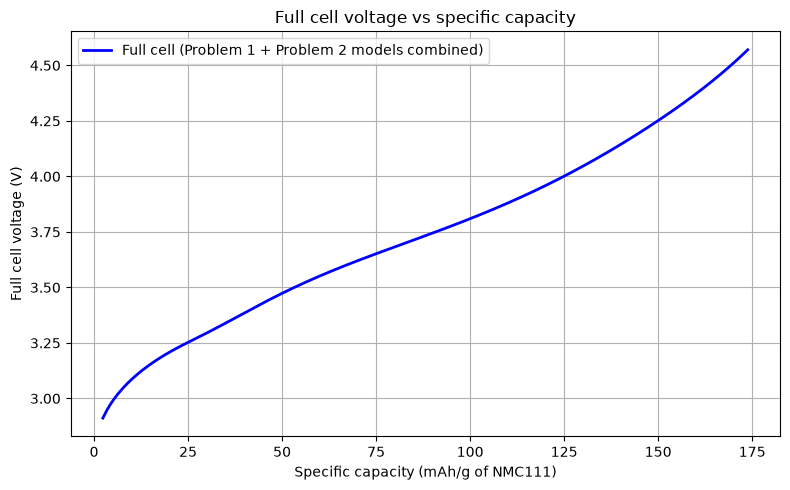

In [ ]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt

F = 96485
R_gas = 8.314
T = 298
Vth = R_gas * T / F

# ---------------- Anode (carbon) parameters, Problem 1 ----------------
Rp_a = 3.5e-6
cmax_a = 18000
D_a = 1e-14
iapp_a = 10.0            # +1 mA/cm^2 : lithiation
U0_a = 0.8170
A_a = {2: 1.9852, 3: 2.6943, 4: -22.52, 5: 42.975, 6: -34.704, 7: 10.276}
B_a = {k: (k - 1) * A_a[k] / Vth for k in A_a}
theta0_a = 5e-4

# ---------------- Cathode (NMC111) parameters, Problem 2 ---------------
Rp_c = 10e-6
cmax_c = 48000
D_c = 7e-15
iapp_c = -10.0            # -1 mA/cm^2 : delithiation
rho_c = 2110.0
theta0_c = 0.99

fit = np.load('cathode_fit_params.npy')
V0_c, O2_c, O3_c, O4_c, O5_c, O6_c, O7_c = fit
Omega_c = {2: O2_c, 3: O3_c, 4: O4_c, 5: O5_c, 6: O6_c, 7: O7_c}
B_c = {k: (k * (k - 1)) * Omega_c[k] / (R_gas * T) for k in Omega_c}

DQ_DTHETA_C = (F * cmax_c) / (3600.0 * rho_c)  # mAh/g per unit theta


def build_anode_sim(t_max, n_t=600):
    model = pybamm.BaseModel()
    r = pybamm.SpatialVariable("r", domain="particle", coord_sys="spherical")
    c = pybamm.Variable("Concentration", domain="particle")

    Dp = pybamm.Parameter("D")
    iapp = pybamm.Parameter("iapp")
    cmax = pybamm.Parameter("cmax")
    U0 = pybamm.Parameter("U0")
    Ap = {k: pybamm.Parameter(f"A{k}") for k in A_a}
    Bp = {k: pybamm.Parameter(f"B{k}") for k in B_a}

    theta = c / cmax
    factor = 1 / (1 - theta) + sum(Bp[k] * theta ** (k - 1) for k in Bp)
    D_eff = Dp * factor
    D_eff_surf = pybamm.surf(D_eff)

    N = -D_eff * pybamm.grad(c)
    model.rhs = {c: -pybamm.div(N)}
    dcdr_R = iapp / F / D_eff_surf
    model.boundary_conditions = {c: {"left": (pybamm.Scalar(0), "Neumann"),
                                      "right": (dcdr_R, "Neumann")}}
    model.initial_conditions = {c: theta0_a * cmax}

    c_surf = pybamm.surf(c)
    theta_surf = c_surf / cmax
    V = U0 + Vth * pybamm.log((1 - theta_surf) / theta_surf) - sum(
        Ap[k] * theta_surf ** (k - 1) for k in Ap)
    model.variables = {"Voltage": V, "Surface occupancy": theta_surf}

    geometry = {"particle": {r: {"min": pybamm.Scalar(0), "max": pybamm.Parameter("Rp")}}}
    values = {"Rp": Rp_a, "D": D_a, "iapp": iapp_a, "cmax": cmax_a, "U0": U0_a}
    values.update({f"A{k}": A_a[k] for k in A_a})
    values.update({f"B{k}": B_a[k] for k in B_a})
    param = pybamm.ParameterValues(values)

    sim = pybamm.Simulation(model, geometry=geometry, parameter_values=param,
                             submesh_types={"particle": pybamm.Uniform1DSubMesh},
                             spatial_methods={"particle": pybamm.FiniteVolume()},
                             var_pts={r: 50},
                             solver=pybamm.ScipySolver(rtol=1e-8, atol=1e-8))
    t_eval = np.linspace(0, t_max, n_t)
    sol = sim.solve(t_eval=t_eval)
    return sol


def build_cathode_sim(t_max, n_t=600):
    model = pybamm.BaseModel()
    r = pybamm.SpatialVariable("r", domain="particle", coord_sys="spherical")
    c = pybamm.Variable("Concentration", domain="particle")

    Dp = pybamm.Parameter("D")
    iapp = pybamm.Parameter("iapp")
    cmax = pybamm.Parameter("cmax")
    V0p = pybamm.Parameter("V0")
    Op = {k: pybamm.Parameter(f"O{k}") for k in Omega_c}
    Bp = {k: pybamm.Parameter(f"B{k}") for k in B_c}

    theta = c / cmax
    # correct cathode thermodynamic factor: 1/(1-theta) + theta * sum_k B_k (1-theta)^(k-2)
    factor = 1 / (1 - theta) + theta * sum(Bp[k] * (1 - theta) ** (k - 2) for k in Bp)
    D_eff = Dp * factor
    D_eff_surf = pybamm.surf(D_eff)

    N = -D_eff * pybamm.grad(c)
    model.rhs = {c: -pybamm.div(N)}
    dcdr_R = iapp / F / D_eff_surf
    model.boundary_conditions = {c: {"left": (pybamm.Scalar(0), "Neumann"),
                                      "right": (dcdr_R, "Neumann")}}
    model.initial_conditions = {c: theta0_c * cmax}

    c_surf = pybamm.surf(c)
    theta_surf = c_surf / cmax
    interaction = sum(k * Op[k] * (1 - theta_surf) ** (k - 1) for k in Op)
    U = V0p + Vth * pybamm.log((1 - theta_surf) / theta_surf) + interaction
    dQ = (F * cmax) / (3600.0 * rho_c)
    capacity = (theta0_c - theta_surf) * dQ

    model.variables = {"Voltage": U, "Specific capacity": capacity, "Surface occupancy": theta_surf}

    geometry = {"particle": {r: {"min": pybamm.Scalar(0), "max": pybamm.Parameter("Rp")}}}
    values = {"Rp": Rp_c, "D": D_c, "iapp": iapp_c, "cmax": cmax_c, "V0": V0_c}
    values.update({f"O{k}": Omega_c[k] for k in Omega_c})
    values.update({f"B{k}": B_c[k] for k in B_c})
    param = pybamm.ParameterValues(values)

    sim = pybamm.Simulation(model, geometry=geometry, parameter_values=param,
                             submesh_types={"particle": pybamm.Uniform1DSubMesh},
                             spatial_methods={"particle": pybamm.FiniteVolume()},
                             var_pts={r: 50},
                             solver=pybamm.ScipySolver(rtol=1e-8, atol=1e-8))
    t_eval = np.linspace(0, t_max, n_t)
    sol = sim.solve(t_eval=t_eval)
    return sol


# ------------------------------------------------------------------
# Run both half cells over a shared, sufficiently long time base, then
# clip to where BOTH electrodes are still within a valid occupancy window.
t_max = 580.0
sol_a = build_anode_sim(t_max, n_t=400)
sol_c = build_cathode_sim(t_max, n_t=400)

t_common = sol_a.t
theta_a = sol_a["Surface occupancy"].entries
V_a = sol_a["Voltage"].entries

theta_c = np.interp(t_common, sol_c.t, sol_c["Surface occupancy"].entries)
V_c = np.interp(t_common, sol_c.t, sol_c["Voltage"].entries)
Q_c = np.interp(t_common, sol_c.t, sol_c["Specific capacity"].entries)

# valid window: both occupancies strictly inside (0,1)
valid = (theta_a > 1e-3) & (theta_a < 0.999) & (theta_c > 1e-3) & (theta_c < 0.999)
t_common, theta_a, V_a, theta_c, V_c, Q_c = [x[valid] for x in
                                              (t_common, theta_a, V_a, theta_c, V_c, Q_c)]

V_full = V_c - V_a

plt.figure(figsize=(8, 5))
plt.plot(Q_c, V_full, 'b-', linewidth=2, label='Full cell (Problem 1 + Problem 2 models combined)')
plt.xlabel('Specific capacity (mAh/g of NMC111)')
plt.ylabel('Full cell voltage (V)')
plt.title('Full cell voltage vs specific capacity')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('Problem3.png', dpi=150)

print("Anode saturates (theta_a -> 1) at t =", t_common[-1] if len(t_common) else None,
      "s ; cathode capacity at that point =", Q_c[-1] if len(Q_c) else None, "mAh/g")
